In [16]:
# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

In [17]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("arwabasal/brain-tumor-mri-detection")

print("Dataset path:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-detection' dataset.
Dataset path: /kaggle/input/brain-tumor-mri-detection


In [18]:
# Show dataset folders
os.listdir(path)

['no', 'yes', 'brain_tumor_dataset']

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image settings
img_size = (128, 128)
batch_size = 32

# Dataset folder
dataset_dir = path + "/brain_tumor_dataset"

# Data preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data
train_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

# Validation data
val_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

# Show classes
print(train_data.class_indices)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
{'no': 0, 'yes': 1}


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Create CNN model
model = Sequential()

# First convolution layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second convolution layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third convolution layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))

# Dropout layer
model.add(Dropout(0.5))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Train the CNN model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 702ms/step - accuracy: 0.5714 - loss: 0.6641 - val_accuracy: 0.7600 - val_loss: 0.5571
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 572ms/step - accuracy: 0.7685 - loss: 0.5093 - val_accuracy: 0.7600 - val_loss: 0.6281
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 564ms/step - accuracy: 0.7882 - loss: 0.4589 - val_accuracy: 0.7600 - val_loss: 0.5174
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 732ms/step - accuracy: 0.8030 - loss: 0.4663 - val_accuracy: 0.7800 - val_loss: 0.5267
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 576ms/step - accuracy: 0.8374 - loss: 0.3779 - val_accuracy: 0.7600 - val_loss: 0.5767
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 580ms/step - accuracy: 0.8424 - loss: 0.3739 - val_accuracy: 0.7800 - val_loss: 0.5310
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 744ms/step - accuracy: 0.8621 - loss: 0.3414 - val_accuracy: 0.7600 - val_loss: 0.4630
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 578ms/step - accuracy: 0.8818 - loss: 0.2914 - val_accuracy: 0.8000 - val_loss:

In [22]:
# Evaluate the model
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8000 - loss: 0.4384
Validation Loss: 0.4383666515350342
Validation Accuracy: 0.800000011920929


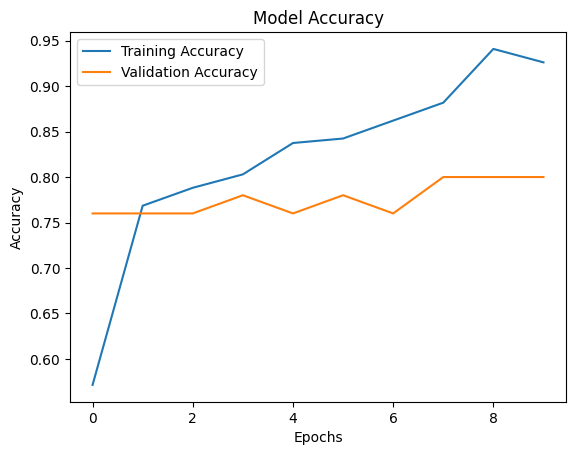

In [23]:
# Plot accuracy graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

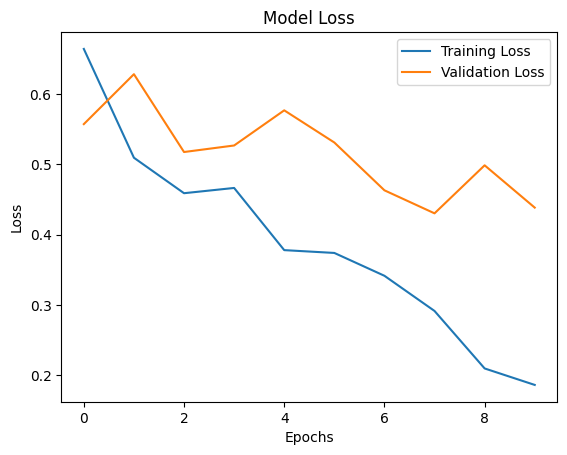

In [24]:
# Plot loss graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict classes
predictions = model.predict(val_data)
predicted_classes = (predictions > 0.5).astype(int)

# True classes
true_classes = val_data.classes

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Confusion Matrix:
[[ 2 17]
 [11 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.15      0.11      0.12        19
           1       0.54      0.65      0.59        31

    accuracy                           0.44        50
   macro avg       0.35      0.38      0.36        50
weighted avg       0.39      0.44      0.41        50



In [26]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

# Load pretrained MobileNetV2 model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# Freeze pretrained layers
base_model.trainable = False

# Create model
mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1, activation='sigmoid')
])

# Compile model
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Show model summary
mobilenet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
# Train MobileNetV2 model
mobilenet_history = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 556ms/step - accuracy: 0.5172 - loss: 0.7626 - val_accuracy: 0.6000 - val_loss: 0.6576
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 279ms/step - accuracy: 0.6305 - loss: 0.6698 - val_accuracy: 0.6200 - val_loss: 0.5700
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 310ms/step - accuracy: 0.7685 - loss: 0.5376 - val_accuracy: 0.8200 - val_loss: 0.4768
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 278ms/step - accuracy: 0.8030 - loss: 0.4918 - val_accuracy: 0.8200 - val_loss: 0.4323
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - accuracy: 0.8424 - loss: 0.4298 - val_accuracy: 0.8000 - val_loss: 0.4277
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 371ms/step - accuracy: 0.8473 - loss: 0.3960 - val_accuracy: 0.8200 - val_loss: 0.3907
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - accuracy: 0.8916 - loss: 0.3614 - val_accuracy: 0.8200 - val_loss: 0.3789
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 281ms/step - accuracy: 0.8916 - loss: 0.3413 - val_accuracy: 0.8200 - val_loss:

In [28]:
# Evaluate MobileNetV2 model
mobile_loss, mobile_accuracy = mobilenet_model.evaluate(val_data)

print("MobileNetV2 Validation Loss:", mobile_loss)
print("MobileNetV2 Validation Accuracy:", mobile_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8200 - loss: 0.3623
MobileNetV2 Validation Loss: 0.3622782826423645
MobileNetV2 Validation Accuracy: 0.8199999928474426


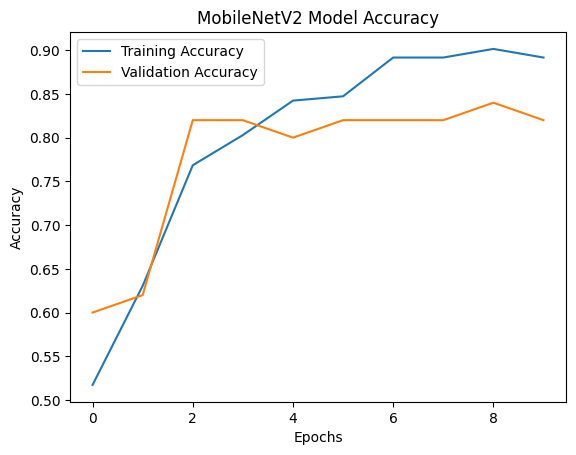

In [29]:
# Plot MobileNetV2 accuracy graph
plt.plot(mobilenet_history.history['accuracy'], label='Training Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('MobileNetV2 Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

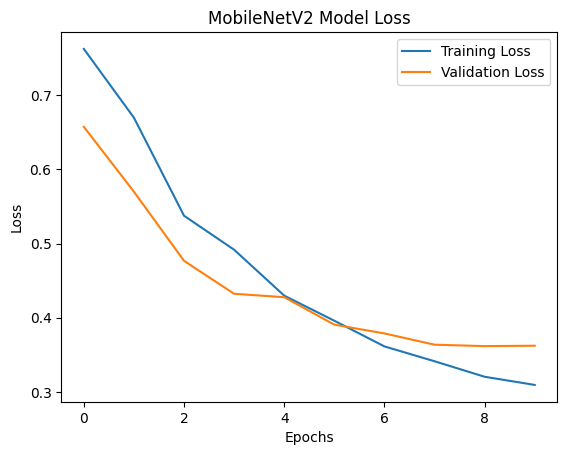

In [30]:
# Plot MobileNetV2 loss graph
plt.plot(mobilenet_history.history['loss'], label='Training Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')

plt.title('MobileNetV2 Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()